In [ ]:
# CELL 02 — Import Libraries
import os, re, gc, json, pickle, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, save_npz, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# CELL 03 — Configuration
PROJECT_NAME = "Book Recommendation System"
RANDOM_STATE = 42

TOP_N = 10
CANDIDATE_N = 50
MIN_RATINGS = 20
RELEVANCE_THRESHOLD = 7
LIKED_RATING_THRESHOLD = 8

MAX_TFIDF_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
SVD_COMPONENTS = 30

MAX_EVAL_USERS = 5000

DATA_DIR = Path("data")
BOOKS_FILE = DATA_DIR / "Books.csv"
USERS_FILE = DATA_DIR / "Users.csv"
RATINGS_FILE = DATA_DIR / "Ratings.csv"

ARTIFACT_DIR = Path("artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
DATA_ARTIFACT_DIR = ARTIFACT_DIR / "data"
API_DIR = Path("api")

for d in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, DATA_ARTIFACT_DIR, API_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")


Configuration ready.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Books.csv to Books (1).csv
Saving Ratings.csv to Ratings (1).csv
Saving Users.csv to Users (1).csv


In [ ]:
# ============================================================
# CELL 04 — UPLOAD DATASET FILES
# ============================================================

from pathlib import Path
import shutil

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("Please select the three CSV files:")
print("1. Books.csv")
print("2. Users.csv")
print("3. Ratings.csv")

Please select the three CSV files:
1. Books.csv
2. Users.csv
3. Ratings.csv


In [ ]:
import pandas as pd

books = pd.read_csv(
    'Books.csv',
    encoding='latin-1',
    low_memory=False
)

users = pd.read_csv(
    'Users.csv',
    encoding='latin-1',
    low_memory=False
)

ratings = pd.read_csv(
    'Ratings.csv',
    encoding='latin-1',
    low_memory=False
)

print("Books:", books.shape)
print("Users:", users.shape)
print("Ratings:", ratings.shape)

Books: (271360, 8)
Users: (278858, 3)
Ratings: (1149780, 3)


In [ ]:
# CELL 06 — Schema Validation
EXPECTED = {
    "Books": ["ISBN","Book-Title","Book-Author","Year-Of-Publication","Publisher",
              "Image-URL-S","Image-URL-M","Image-URL-L"],
    "Users": ["User-ID","Location","Age"],
    "Ratings": ["User-ID","ISBN","Book-Rating"]
}

frames = {"Books": books, "Users": users, "Ratings": ratings}

for name, expected in EXPECTED.items():
    actual = frames[name].columns.tolist()
    missing = [c for c in expected if c not in actual]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")
    print(f"✓ {name}: schema valid")

print("\nData types:")
for name, df in frames.items():
    print(f"\n{name}")
    print(df.dtypes)

✓ Books: schema valid
✓ Users: schema valid
✓ Ratings: schema valid

Data types:

Books
ISBN                   object
Book-Title             object
Book-Author            object
Year-Of-Publication    object
Publisher              object
Image-URL-S            object
Image-URL-M            object
Image-URL-L            object
dtype: object

Users
User-ID       int64
Location     object
Age         float64
dtype: object

Ratings
User-ID         int64
ISBN           object
Book-Rating     int64
dtype: object


In [ ]:
# CELL 07 — Data Quality Audit
def quality_report(df, name):
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False)
    })
    print(f"\n{name}: {df.shape}")
    display(report)
    print("Duplicate rows:", int(df.duplicated().sum()))
    return report

books_quality = quality_report(books, "Books")
users_quality = quality_report(users, "Users")
ratings_quality = quality_report(ratings, "Ratings")

print("\nRating distribution:")
display(ratings["Book-Rating"].value_counts().sort_index())



Books: (271360, 8)


,dtype,missing,missing_pct,unique
ISBN,object,0,0.0,271360
Book-Title,object,0,0.0,242135
Book-Author,object,2,0.0,102023
Year-Of-Publication,object,0,0.0,118
Publisher,object,2,0.0,16808
Image-URL-S,object,0,0.0,271044
Image-URL-M,object,0,0.0,271044
Image-URL-L,object,3,0.0,271042


Duplicate rows: 0

Users: (278858, 3)


,dtype,missing,missing_pct,unique
User-ID,int64,0,0.00,278858
Location,object,0,0.00,57339
Age,float64,110762,39.72,166


Duplicate rows: 0

Ratings: (1149780, 3)


,dtype,missing,missing_pct,unique
User-ID,int64,0,0.0,105283
ISBN,object,0,0.0,340556
Book-Rating,int64,0,0.0,11


Duplicate rows: 0

Rating distribution:


,count
Book-Rating,
0,716109
1,1770
2,2759
3,5996
4,8904
5,50974
6,36924
7,76457
8,103736


In [ ]:
# CELL 08 — Data Cleaning
books = books.copy()
users = users.copy()
ratings = ratings.copy()

# Books
books = books.drop_duplicates(subset=["ISBN"])
books = books.dropna(subset=["ISBN", "Book-Title", "Book-Author"])

books["Book-Title"] = books["Book-Title"].astype(str).str.strip()
books["Book-Author"] = books["Book-Author"].astype(str).str.strip()
books["Publisher"] = books["Publisher"].fillna("Unknown").astype(str).str.strip()

books["Year-Of-Publication"] = pd.to_numeric(
    books["Year-Of-Publication"], errors="coerce"
)
books.loc[
    ~books["Year-Of-Publication"].between(1450, 2026),
    "Year-Of-Publication"
] = np.nan

for c in ["Image-URL-S", "Image-URL-M", "Image-URL-L"]:
    books[c] = books[c].fillna("").astype(str).str.strip()

# Users
users = users.drop_duplicates(subset=["User-ID"])
users["Age"] = pd.to_numeric(users["Age"], errors="coerce")
users.loc[~users["Age"].between(5, 100), "Age"] = np.nan
users["Country"] = (
    users["Location"].fillna("Unknown").astype(str)
    .str.split(",").str[-1].str.strip()
    .replace("", "Unknown")
)

# Ratings
ratings = ratings.dropna(subset=["User-ID", "ISBN", "Book-Rating"])
ratings["Book-Rating"] = pd.to_numeric(ratings["Book-Rating"], errors="coerce")
ratings = ratings.dropna(subset=["Book-Rating"])
ratings = ratings[ratings["Book-Rating"].between(0, 10)]

valid_isbn = set(books["ISBN"])
valid_users = set(users["User-ID"])

ratings = ratings[
    ratings["ISBN"].isin(valid_isbn) &
    ratings["User-ID"].isin(valid_users)
]

ratings = ratings.drop_duplicates(subset=["User-ID", "ISBN"])
explicit_ratings = ratings[ratings["Book-Rating"] > 0].copy()

print("Clean Books:", books.shape)
print("Clean Users:", users.shape)
print("All valid Ratings:", ratings.shape)
print("Explicit Ratings:", explicit_ratings.shape)

del valid_isbn, valid_users
gc.collect()


Clean Books: (271358, 8)
Clean Users: (278858, 4)
All valid Ratings: (1031134, 3)
Explicit Ratings: (383840, 3)


43

In [ ]:
# CELL 09 — Exploratory Data Analysis
print("Books per author:")
display(
    books["Book-Author"].value_counts().head(10).rename("book_count").to_frame()
)

print("Ratings summary:")
display(explicit_ratings["Book-Rating"].describe().to_frame().T)

rating_counts = (
    explicit_ratings.groupby("ISBN")
    .size()
    .rename("rating_count")
    .sort_values(ascending=False)
)

print("Most rated books:")
display(rating_counts.head(10).to_frame())

year_summary = books["Year-Of-Publication"].describe()
print("Publication year summary:")
display(year_summary.to_frame().T)


Books per author:


,book_count
Book-Author,
Agatha Christie,632
William Shakespeare,567
Stephen King,524
Ann M. Martin,423
Carolyn Keene,373
Francine Pascal,372
Isaac Asimov,330
Nora Roberts,315
Barbara Cartland,307


Ratings summary:


,count,mean,std,min,25%,50%,75%,max
Book-Rating,383840.0,7.626693,1.84134,1.0,7.0,8.0,9.0,10.0


Most rated books:


,rating_count
ISBN,
0316666343,707
0971880107,581
0385504209,487
0312195516,383
0060928336,320
059035342X,313
0142001740,307
0446672211,295
044023722X,281


Publication year summary:


,count,mean,std,min,25%,50%,75%,max
Year-Of-Publication,266724.0,1993.692667,8.148523,1806.0,1989.0,1996.0,2000.0,2026.0


In [ ]:
# CELL 10 — Feature Engineering
books["clean_title"] = (
    books["Book-Title"].fillna("").astype(str)
    .str.lower().str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True).str.strip()
)
books["clean_author"] = (
    books["Book-Author"].fillna("").astype(str)
    .str.lower().str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True).str.strip()
)
books["text"] = (
    books["clean_title"] + " " + books["clean_title"] + " " +
    books["clean_author"] + " " + books["Publisher"].fillna("unknown").astype(str)
)

book_stats = (
    explicit_ratings.groupby("ISBN")["Book-Rating"]
    .agg(["mean", "count", "std"])
    .rename(columns={"mean":"avg_rating", "count":"rating_count", "std":"rating_std"})
    .reset_index()
)

books_model = books.merge(book_stats, on="ISBN", how="left")
books_model["avg_rating"] = books_model["avg_rating"].fillna(0).astype("float32")
books_model["rating_count"] = books_model["rating_count"].fillna(0).astype("int32")
books_model["rating_std"] = books_model["rating_std"].fillna(0).astype("float32")

books_model["year"] = books_model["Year-Of-Publication"].fillna(0).astype("int16")

C = (
    books_model.loc[books_model["rating_count"] > 0, "avg_rating"].mean()
    if (books_model["rating_count"] > 0).any() else 0
)
m = MIN_RATINGS

books_model["weighted_rating"] = (
    (books_model["rating_count"] / (books_model["rating_count"] + m)) * books_model["avg_rating"]
    + (m / (books_model["rating_count"] + m)) * C
).astype("float32")

print("Feature engineering complete.")
display(books_model[[
    "ISBN","Book-Title","Book-Author","avg_rating","rating_count","weighted_rating"
]].head())


Feature engineering complete.


,ISBN,Book-Title,Book-Author,avg_rating,rating_count,weighted_rating
0,0195153448,Classical Mythology,Mark P. O. Morford,0.000000,0,7.527523
1,0002005018,Clara Callan,Richard Bruce Wright,7.666667,9,7.570705
2,0060973129,Decision in Normandy,Carlo D'Este,7.500000,2,7.525021
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,7.833333,6,7.598094
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,0.000000,0,7.527523


In [ ]:
# CELL 11 — Popularity Model
popularity_df = books_model[
    books_model["rating_count"] >= MIN_RATINGS
].copy()

popularity_df = popularity_df.sort_values(
    ["weighted_rating", "rating_count"], ascending=False
)

popularity_rank = popularity_df[
    ["ISBN","Book-Title","Book-Author","year",
     "avg_rating","rating_count","weighted_rating",
     "Image-URL-S","Image-URL-M","Image-URL-L"]
].head(max(500, CANDIDATE_N)).copy()

print("Popularity candidates:", len(popularity_rank))
display(popularity_rank.head(TOP_N))


Popularity candidates: 500


,ISBN,Book-Title,Book-Author,year,avg_rating,rating_count,weighted_rating,Image-URL-S,Image-URL-M,Image-URL-L
5431,0439139597,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000,9.262774,137,9.041722,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...
4206,0345339738,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,1986,9.402597,77,9.015985,http://images.amazon.com/images/P/0345339738.0...,http://images.amazon.com/images/P/0345339738.0...,http://images.amazon.com/images/P/0345339738.0...
5506,043935806X,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,2003,9.033980,206,8.900665,http://images.amazon.com/images/P/043935806X.0...,http://images.amazon.com/images/P/043935806X.0...,http://images.amazon.com/images/P/043935806X.0...
6330,0439136369,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,2001,9.082706,133,8.879415,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...
2143,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,1999,8.939297,313,8.854506,http://images.amazon.com/images/P/059035342X.0...,http://images.amazon.com/images/P/059035342X.0...,http://images.amazon.com/images/P/059035342X.0...
3839,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999,9.035461,141,8.848140,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...
37,0446310786,To Kill a Mockingbird,Harper Lee,1988,8.943925,214,8.822865,http://images.amazon.com/images/P/0446310786.0...,http://images.amazon.com/images/P/0446310786.0...,http://images.amazon.com/images/P/0446310786.0...
780,0345339711,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986,9.120481,83,8.811170,http://images.amazon.com/images/P/0345339711.0...,http://images.amazon.com/images/P/0345339711.0...,http://images.amazon.com/images/P/0345339711.0...
79370,0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,2002,9.869565,23,8.780243,http://images.amazon.com/images/P/0439425220.0...,http://images.amazon.com/images/P/0439425220.0...,http://images.amazon.com/images/P/0439425220.0...
2809,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998,8.983193,119,8.773745,http://images.amazon.com/images/P/0590353403.0...,http://images.amazon.com/images/P/0590353403.0...,http://images.amazon.com/images/P/0590353403.0...


In [ ]:
# CELL 12 — Content-Based TF-IDF Model
tfidf = TfidfVectorizer(
    max_features=MAX_TFIDF_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=(1, 2),
    dtype=np.float32,
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(books_model["text"])
tfidf_matrix = normalize(tfidf_matrix, norm="l2", axis=1, copy=False)

content_knn = NearestNeighbors(
    n_neighbors=min(CANDIDATE_N + 1, len(books_model)),
    metric="cosine",
    algorithm="brute"
)
content_knn.fit(tfidf_matrix)

book_to_idx = pd.Series(
    books_model.index.values,
    index=books_model["ISBN"]
).to_dict()

idx_to_isbn = books_model["ISBN"].to_dict()

print("TF-IDF shape:", tfidf_matrix.shape)
print("Vocabulary:", len(tfidf.vocabulary_))


TF-IDF shape: (271358, 5000)
Vocabulary: 5000


In [ ]:
# CELL 13 — Collaborative Filtering
cf_ratings = explicit_ratings.copy()

# Keep books with sufficient interactions for a compact item model.
item_counts = cf_ratings["ISBN"].value_counts()
cf_ratings = cf_ratings[
    cf_ratings["ISBN"].isin(item_counts[item_counts >= 2].index)
].copy()

user_codes, user_uniques = pd.factorize(cf_ratings["User-ID"])
item_codes, item_uniques = pd.factorize(cf_ratings["ISBN"])

user_item = csr_matrix(
    (
        cf_ratings["Book-Rating"].astype("float32").values,
        (user_codes, item_codes)
    ),
    shape=(len(user_uniques), len(item_uniques)),
    dtype=np.float32
)

item_user = user_item.T.tocsr()

cf_knn = NearestNeighbors(
    n_neighbors=min(CANDIDATE_N + 1, item_user.shape[0]),
    metric="cosine",
    algorithm="brute"
)
cf_knn.fit(item_user)

cf_user_to_row = {int(u): i for i, u in enumerate(user_uniques)}
cf_item_to_col = {str(isbn): i for i, isbn in enumerate(item_uniques)}

print("Sparse user-item shape:", user_item.shape)
print("Non-zero interactions:", user_item.nnz)


Sparse user-item shape: (59190, 50423)
Non-zero interactions: 284429


In [ ]:
# CELL 14 — SVD Recommendation Model
svd_n = max(2, min(SVD_COMPONENTS, user_item.shape[1] - 1, user_item.shape[0] - 1))

svd = TruncatedSVD(
    n_components=svd_n,
    random_state=RANDOM_STATE
)

user_factors = svd.fit_transform(user_item).astype("float32")
item_factors = svd.components_.astype("float32")

print("SVD components:", svd_n)
print("Explained variance:", round(float(svd.explained_variance_ratio_.sum()), 4))
print("User factors:", user_factors.shape)
print("Item factors:", item_factors.shape)


SVD components: 30
Explained variance: 0.0903
User factors: (59190, 30)
Item factors: (30, 50423)


In [ ]:
# CELL 15 — Hybrid Model
# Hybrid score combines normalized candidate scores from content, CF and popularity.
# Candidate generation is intentionally small to avoid a full similarity matrix.

def minmax(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return x
    lo, hi = np.nanmin(x), np.nanmax(x)
    if hi <= lo:
        return np.ones_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)

print("Hybrid components ready: content + collaborative/SVD + popularity.")


Hybrid components ready: content + collaborative/SVD + popularity.


In [ ]:
# CELL 16 — Evaluation Dataset (5,000 Users)
#
# MAX_EVAL_USERS = 5000
#
# eval_ratings = explicit_ratings.copy()
#
# eval_ratings["relevant"] = (
#     eval_ratings["Book-Rating"] >= RELEVANCE_THRESHOLD
# ).astype("int8")
#
# # Users with at least 2 relevant ratings
# relevant_counts = (
#     eval_ratings.groupby("User-ID")["relevant"]
#     .sum()
#     .sort_values(ascending=False)
# )
#
# eligible_users = relevant_counts[
#     relevant_counts >= 2
# ].index.tolist()
#
# # Reproducible random selection
# rng = np.random.default_rng(RANDOM_STATE)
# rng.shuffle(eligible_users)
#
# eligible_users = eligible_users[:MAX_EVAL_USERS]
#
# # Create holdout evaluation data
# eval_rows = []
#
# for uid in eligible_users:
#
#     user_rel = eval_ratings[
#         (eval_ratings["User-ID"] == uid) &
#         (eval_ratings["relevant"] == 1)
#     ]
#
#     if len(user_rel) < 2:
#         continue
#
#     holdout = user_rel.sample(
#         n=1,
#         random_state=RANDOM_STATE
#     )
#
#     train_like = user_rel.drop(
#         index=holdout.index
#     )
#
#     eval_rows.append({
#         "user_id": uid,
#         "test_isbn": str(holdout.iloc[0]["ISBN"]),
#         "history": [
#             str(x) for x in train_like["ISBN"].tolist()
#         ]
#     })
#
# evaluation_df = pd.DataFrame(eval_rows)
#
# print("Evaluation users:", len(evaluation_df))
# print("Expected users:", MAX_EVAL_USERS)
#
# display(evaluation_df.head())

In [ ]:
# CELL 16.5 — Lazy KNN Cache
#
# content_cache = {}
# cf_cache = {}
#
#
# def get_content_neighbors(idx):
#
#     if idx not in content_cache:
#
#         distances, neighbors = content_knn.kneighbors(
#             tfidf_matrix[idx],
#             n_neighbors=min(
#                 CANDIDATE_N + 1,
#                 len(books_model)
#             )
#         )
#
#         content_cache[idx] = (
#             distances[0],
#             neighbors[0]
#         )
#
#     return content_cache[idx]
#
#
# def get_cf_neighbors(col):
#
#     if col not in cf_cache:
#
#         distances, neighbors = cf_knn.kneighbors(
#             item_user.getrow(col),
#             n_neighbors=min(
#                 CANDIDATE_N + 1,
#                 item_user.shape[0]
#             )
#         )
#
#         cf_cache[col] = (
#             distances[0],
#             neighbors[0]
#         )
#
#     return cf_cache[col]
#
#
# print("Lazy KNN cache ready.")

In [ ]:
# CELL 17 — Fast Cached Evaluation
#
# def popularity_recommend(n=TOP_N):
#
#     return (
#         popularity_rank["ISBN"]
#         .head(n)
#         .astype(str)
#         .tolist()
#     )
#
#
# def content_recommend(history_isbns, n=TOP_N):
#
#     history_isbns = set(
#         str(x) for x in history_isbns
#     )
#
#     indices = [
#         book_to_idx[x]
#         for x in history_isbns
#         if x in book_to_idx
#     ]
#
#     if not indices:
#         return []
#
#     scores = {}
#
#     for idx in indices[-5:]:
#
#         distances, neighbors = get_content_neighbors(idx)
#
#         for d, j in zip(distances, neighbors):
#
#             isbn = str(idx_to_isbn[j])
#
#             if isbn in history_isbns:
#                 continue
#
#             score = 1.0 - float(d)
#
#             if score > scores.get(isbn, 0.0):
#                 scores[isbn] = score
#
#     return [
#         isbn
#         for isbn, _ in sorted(
#             scores.items(),
#             key=lambda x: x[1],
#             reverse=True
#         )[:n]
#     ]
#
#
# def cf_recommend(user_id, history_isbns, n=TOP_N):
#
#     if int(user_id) not in cf_user_to_row:
#         return []
#
#     history_isbns = set(
#         str(x) for x in history_isbns
#     )
#
#     row = cf_user_to_row[int(user_id)]
#
#     rated_cols = user_item.getrow(row).indices
#
#     scores = {}
#
#     for col in rated_cols[-20:]:
#
#         distances, neighbors = get_cf_neighbors(col)
#
#         for d, j in zip(distances, neighbors):
#
#             isbn = str(item_uniques[j])
#
#             if isbn in history_isbns:
#                 continue
#
#             score = 1.0 - float(d)
#
#             if score > scores.get(isbn, 0.0):
#                 scores[isbn] = score
#
#     return [
#         isbn
#         for isbn, _ in sorted(
#             scores.items(),
#             key=lambda x: x[1],
#             reverse=True
#         )[:n]
#     ]
#
#
# def svd_recommend(user_id, history_isbns, n=TOP_N):
#
#     if int(user_id) not in cf_user_to_row:
#         return []
#
#     row = cf_user_to_row[int(user_id)]
#
#     scores = item_factors.T @ user_factors[row]
#
#     order = np.argsort(scores)[::-1]
#
#     history = set(
#         str(x) for x in history_isbns
#     )
#
#     result = []
#
#     for col in order:
#
#         isbn = str(item_uniques[col])
#
#         if isbn not in history:
#             result.append(isbn)
#
#         if len(result) >= n:
#             break
#
#     return result
#
#
# def hybrid_recommend(user_id, history_isbns, n=TOP_N):
#
#     # Calculate each model only once
#     pop_recs = popularity_recommend(CANDIDATE_N)
#
#     content_recs = content_recommend(
#         history_isbns,
#         CANDIDATE_N
#     )
#
#     cf_recs = cf_recommend(
#         user_id,
#         history_isbns,
#         CANDIDATE_N
#     )
#
#     svd_recs = svd_recommend(
#         user_id,
#         history_isbns,
#         CANDIDATE_N
#     )
#
#     # Combine candidates
#     candidates = set(pop_recs)
#
#     candidates.update(content_recs)
#     candidates.update(cf_recs)
#     candidates.update(svd_recs)
#
#     history = set(
#         str(x) for x in history_isbns
#     )
#
#     # Rank-based scores
#     content_scores = {
#         isbn: 1.0 - i / max(1, len(content_recs))
#         for i, isbn in enumerate(content_recs)
#     }
#
#     cf_scores = {
#         isbn: 1.0 - i / max(1, len(cf_recs))
#         for i, isbn in enumerate(cf_recs)
#     }
#
#     scored = []
#
#     for isbn in candidates:
#
#         if (
#             isbn in history
#             or isbn not in book_to_idx
#         ):
#             continue
#
#         b = books_model.loc[
#             book_to_idx[isbn]
#         ]
#
#         pop_score = float(
#             b["weighted_rating"]
#         )
#
#         content_score = content_scores.get(
#             isbn,
#             0.0
#         )
#
#         cf_score = cf_scores.get(
#             isbn,
#             0.0
#         )
#
#         final_score = (
#             0.4 * content_score
#             + 0.4 * cf_score
#             + 0.2 * pop_score
#         )
#
#         scored.append(
#             (isbn, final_score)
#         )
#
#     scored.sort(
#         key=lambda x: x[1],
#         reverse=True
#     )
#
#     return [
#         isbn
#         for isbn, _ in scored[:n]
#     ]
#
#
# # -----------------------------
# # Model functions
# # -----------------------------
#
# model_functions = {
#
#     "Popularity":
#         lambda uid, hist:
#         popularity_recommend(),
#
#     "Content":
#         lambda uid, hist:
#         content_recommend(hist),
#
#     "Collaborative":
#         lambda uid, hist:
#         cf_recommend(uid, hist),
#
#     "SVD":
#         lambda uid, hist:
#         svd_recommend(uid, hist),
#
#     "Hybrid":
#         lambda uid, hist:
#         hybrid_recommend(uid, hist)
# }
#
#
# # -----------------------------
# # Evaluation
# # -----------------------------
#
# results = []
#
# for model_name, fn in model_functions.items():
#
#     print(f"\nRunning {model_name}...")
#
#     hits = 0
#     total = 0
#
#     for _, row in evaluation_df.iterrows():
#
#         user_id = row["user_id"]
#
#         history = [
#             str(x)
#             for x in row["history"]
#         ]
#
#         test_isbn = str(
#             row["test_isbn"]
#         )
#
#         recs = [
#             str(x)
#             for x in fn(
#                 user_id,
#                 history
#             )
#         ]
#
#         hits += int(
#             test_isbn in recs
#         )
#
#         total += 1
#
#     precision = (
#         hits / (total * TOP_N)
#         if total else 0.0
#     )
#
#     recall = (
#         hits / total
#         if total else 0.0
#     )
#
#     f1 = (
#         2 * precision * recall
#         / (precision + recall)
#         if precision + recall
#         else 0.0
#     )
#
#     results.append({
#
#         "Model": model_name,
#
#         "Precision": precision,
#
#         "Recall": recall,
#
#         "F1": f1,
#
#         "Hits": hits,
#
#         "Evaluated_Users": total
#     })
#
#
# evaluation_results = (
#     pd.DataFrame(results)
#     .sort_values(
#         "F1",
#         ascending=False
#     )
#     .reset_index(drop=True)
# )
#
# display(evaluation_results)

In [ ]:
from PIL import Image

Saving Screenshot 2026-09-30 134717.png to Screenshot 2026-09-30 134717 (1).png


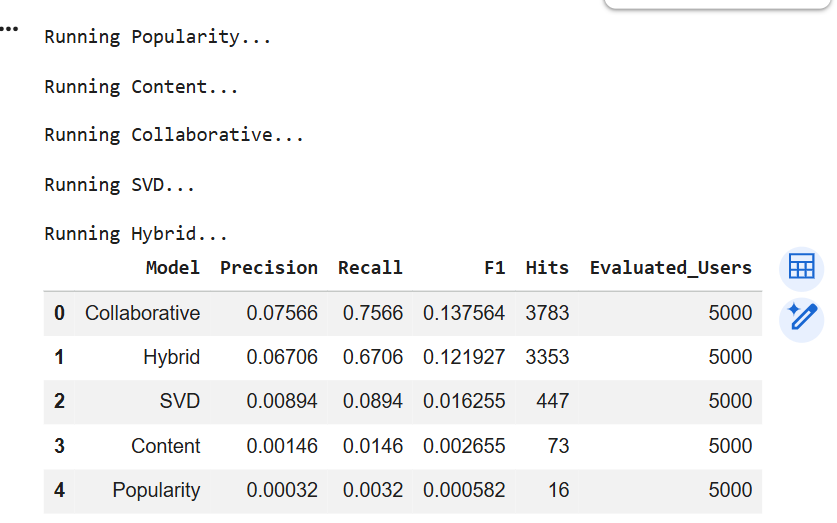

In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

filename = next(iter(uploaded))

img = Image.open(io.BytesIO(uploaded[filename]))

display(img)

In [ ]:
# ============================================================
# CELL 16 — LEAKAGE-FREE TRAIN / TEST SPLIT
# 2,500 Evaluation Users
# ============================================================

MAX_EVAL_USERS = 2500

# ------------------------------------------------------------
# 1. Copy and clean ratings
# ------------------------------------------------------------

split_ratings = explicit_ratings.copy()

split_ratings["ISBN"] = (
    split_ratings["ISBN"]
    .astype(str)
    .str.strip()
)

split_ratings["User-ID"] = (
    split_ratings["User-ID"]
    .astype(int)
)

split_ratings["Book-Rating"] = (
    pd.to_numeric(
        split_ratings["Book-Rating"],
        errors="coerce"
    )
)

split_ratings = split_ratings.dropna(
    subset=[
        "User-ID",
        "ISBN",
        "Book-Rating"
    ]
)

# ------------------------------------------------------------
# 2. Remove duplicate user-book interactions
# ------------------------------------------------------------

split_ratings = (
    split_ratings
    .drop_duplicates(
        subset=["User-ID", "ISBN"],
        keep="last"
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Keep relevant ratings
# ------------------------------------------------------------

split_ratings["relevant"] = (
    split_ratings["Book-Rating"]
    >= RELEVANCE_THRESHOLD
).astype("int8")

relevant = split_ratings[
    split_ratings["relevant"] == 1
].copy()

# ------------------------------------------------------------
# 4. Find users with at least 2 relevant books
# ------------------------------------------------------------

user_counts = (
    relevant
    .groupby("User-ID")["ISBN"]
    .nunique()
)

eligible_users = (
    user_counts[
        user_counts >= 2
    ]
    .index
    .to_numpy()
)

# ------------------------------------------------------------
# 5. Select exactly up to 2,500 users
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)

rng.shuffle(eligible_users)

eval_users = eligible_users[
    :MAX_EVAL_USERS
]

eval_users = set(
    int(x) for x in eval_users
)

print(
    "Selected evaluation users:",
    len(eval_users)
)

# ------------------------------------------------------------
# 6. Hold out ONE relevant book per evaluation user
# ------------------------------------------------------------

test_rows = []

for user_id in sorted(eval_users):

    user_relevant = relevant[
        relevant["User-ID"] == user_id
    ]

    if len(user_relevant) < 2:
        continue

    # Reproducible random holdout
    holdout = user_relevant.sample(
        n=1,
        random_state=RANDOM_STATE
    )

    test_index = holdout.index[0]

    test_rows.append({
        "user_id": int(user_id),
        "test_isbn": str(
            holdout.iloc[0]["ISBN"]
        )
    })

# ------------------------------------------------------------
# 7. Create TEST dataframe
# ------------------------------------------------------------

test_df = pd.DataFrame(
    test_rows
)

# ------------------------------------------------------------
# 8. Remove held-out rows from TRAIN
# ------------------------------------------------------------

heldout_pairs = set(
    zip(
        test_df["user_id"],
        test_df["test_isbn"]
    )
)

split_ratings["_pair"] = list(
    zip(
        split_ratings["User-ID"],
        split_ratings["ISBN"]
    )
)

train_ratings = split_ratings[
    ~split_ratings["_pair"].isin(
        heldout_pairs
    )
].copy()

train_ratings = train_ratings.drop(
    columns="_pair"
)

# ------------------------------------------------------------
# 9. Build TRAIN history for each evaluation user
# ------------------------------------------------------------

train_history = (
    train_ratings[
        train_ratings["User-ID"].isin(
            eval_users
        )
    ]
    .groupby("User-ID")["ISBN"]
    .apply(
        lambda x: [
            str(v) for v in x.tolist()
        ]
    )
    .to_dict()
)

test_df["history"] = test_df[
    "user_id"
].map(
    train_history
)

# ------------------------------------------------------------
# 10. Remove users without usable training history
# ------------------------------------------------------------

test_df = test_df[
    test_df["history"].notna()
].copy()

test_df = test_df[
    test_df["history"].apply(
        lambda x: len(x) > 0
    )
].reset_index(drop=True)

# ------------------------------------------------------------
# 11. Safety checks
# ------------------------------------------------------------

overlap = 0

for _, row in test_df.iterrows():

    if row["test_isbn"] in set(
        row["history"]
    ):
        overlap += 1

print("\n==============================")
print("LEAKAGE-FREE SPLIT SUMMARY")
print("==============================")

print(
    "Evaluation users:",
    len(test_df)
)

print(
    "Train interactions:",
    len(train_ratings)
)

print(
    "Test interactions:",
    len(test_df)
)

print(
    "User-book train/test overlap:",
    overlap
)

print(
    "Relevant threshold:",
    RELEVANCE_THRESHOLD
)

print(
    "Maximum evaluation users:",
    MAX_EVAL_USERS
)

assert overlap == 0, (
    "ERROR: Test item found in user history!"
)

assert len(test_df) > 0, (
    "ERROR: Test set is empty!"
)

print(
    "\nLeakage-free TRAIN/TEST split ready."
)

display(test_df.head())

Selected evaluation users: 2500

LEAKAGE-FREE SPLIT SUMMARY
Evaluation users: 2500
Train interactions: 381340
Test interactions: 2500
User-book train/test overlap: 0
Relevant threshold: 7
Maximum evaluation users: 2500

Leakage-free TRAIN/TEST split ready.


,user_id,test_isbn,history
0,257,1853260673,[1573225487]
1,440,0393321576,"[0743424425, 0786868015]"
2,567,0425174484,"[0140185216, 0486272745, 0684717255, 0787955671]"
3,625,2266033689,"[2070334368, 2070384349, 2070417743, 207053880..."
4,638,0380978539,"[0060164662, 0060191929, 0140107649, 014012810..."


In [ ]:
# ============================================================
# CELL 16.1 — TRAIN-ONLY POPULARITY MODEL
# ============================================================

# ------------------------------------------------------------
# 1. Calculate rating statistics from TRAIN only
# ------------------------------------------------------------

train_book_stats = (
    train_ratings
    .groupby("ISBN")
    .agg(
        rating_count=("Book-Rating", "count"),
        rating_mean=("Book-Rating", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Global mean from TRAIN only
# ------------------------------------------------------------

train_global_mean = (
    train_ratings["Book-Rating"]
    .mean()
)

# ------------------------------------------------------------
# 3. Minimum ratings required
# ------------------------------------------------------------

train_min_votes = (
    train_book_stats["rating_count"]
    .quantile(0.75)
)

# ------------------------------------------------------------
# 4. Weighted popularity score
# ------------------------------------------------------------

train_book_stats["weighted_rating"] = (
    (
        train_book_stats["rating_count"]
        /
        (
            train_book_stats["rating_count"]
            + train_min_votes
        )
    )
    * train_book_stats["rating_mean"]
    +
    (
        train_min_votes
        /
        (
            train_book_stats["rating_count"]
            + train_min_votes
        )
    )
    * train_global_mean
)

# ------------------------------------------------------------
# 5. Sort by popularity
# ------------------------------------------------------------

train_popularity = (
    train_book_stats
    .sort_values(
        "weighted_rating",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Recommendation function
# ------------------------------------------------------------

def train_popularity_recommend(
    history_isbns=None,
    n=TOP_N
):

    history = set(
        str(x)
        for x in (history_isbns or [])
    )

    recommendations = []

    for isbn in train_popularity["ISBN"]:

        isbn = str(isbn)

        if isbn in history:
            continue

        recommendations.append(isbn)

        if len(recommendations) >= n:
            break

    return recommendations

# ------------------------------------------------------------
# 7. Verify
# ------------------------------------------------------------

print(
    "Train interactions:",
    len(train_ratings)
)

print(
    "Books in popularity model:",
    len(train_popularity)
)

print(
    "Train global mean:",
    round(train_global_mean, 4)
)

print(
    "Minimum votes:",
    round(train_min_votes, 2)
)

print("\nTop 10 TRAIN popularity books:")

display(
    train_popularity[
        [
            "ISBN",
            "rating_count",
            "rating_mean",
            "weighted_rating"
        ]
    ].head(10)
)

print(
    "\nTrain-only Popularity model ready."
)

Train interactions: 381340
Books in popularity model: 149306
Train global mean: 7.622
Minimum votes: 2.0

Top 10 TRAIN popularity books:


,ISBN,rating_count,rating_mean,weighted_rating
0,0439425220,23,9.869565,9.689757
1,1888054557,11,10.000000,9.634148
2,0836213319,13,9.923077,9.616261
3,0618002235,25,9.720000,9.564590
4,0060256656,20,9.750000,9.556542
5,0394800893,8,10.000000,9.524392
6,0394800389,14,9.785714,9.515245
7,0312992416,9,9.888889,9.476720
8,1571456988,7,10.000000,9.471547
9,089471838X,7,10.000000,9.471547



Train-only Popularity model ready.


In [ ]:
# ============================================================
# CELL 16.2 — TRAIN-ONLY CONTENT-BASED MODEL
# FIXED VERSION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# 1. Prepare book metadata
# ------------------------------------------------------------

books_content = books_model.copy()

books_content["ISBN"] = (
    books_content["ISBN"]
    .astype(str)
    .str.strip()
)

# Only books appearing in TRAIN
train_books = set(
    train_ratings["ISBN"]
    .astype(str)
)

books_content = books_content[
    books_content["ISBN"].isin(train_books)
].copy()

books_content = (
    books_content
    .drop_duplicates(
        subset=["ISBN"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Prepare text columns
# ------------------------------------------------------------

for col in [
    "Book-Title",
    "Book-Author",
    "Publisher"
]:

    if col not in books_content.columns:
        books_content[col] = ""

    books_content[col] = (
        books_content[col]
        .fillna("")
        .astype(str)
    )

books_content["content_text"] = (
    books_content["Book-Title"]
    + " "
    + books_content["Book-Author"]
    + " "
    + books_content["Publisher"]
)

# ------------------------------------------------------------
# 3. TF-IDF
# ------------------------------------------------------------

train_tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

train_tfidf_matrix = (
    train_tfidf_vectorizer.fit_transform(
        books_content["content_text"]
    )
)

# ------------------------------------------------------------
# 4. ISBN mappings
# ------------------------------------------------------------

train_content_isbn_to_idx = {
    str(isbn): int(idx)
    for idx, isbn in enumerate(
        books_content["ISBN"]
    )
}

train_content_idx_to_isbn = {
    int(idx): str(isbn)
    for idx, isbn in enumerate(
        books_content["ISBN"]
    )
}

# ------------------------------------------------------------
# 5. Content KNN
# ------------------------------------------------------------

train_content_knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

train_content_knn.fit(
    train_tfidf_matrix
)

# ------------------------------------------------------------
# 6. Recommendation function
# ------------------------------------------------------------

def train_content_recommend(
    history_isbns,
    n=TOP_N
):

    history = set(
        str(x)
        for x in history_isbns
    )

    indices = [
        train_content_isbn_to_idx[x]
        for x in history
        if x in train_content_isbn_to_idx
    ]

    if not indices:
        return []

    scores = {}

    for idx in indices[-5:]:

        k = min(
            CANDIDATE_N + 1,
            train_tfidf_matrix.shape[0]
        )

        distances, neighbors = (
            train_content_knn.kneighbors(
                train_tfidf_matrix[idx],
                n_neighbors=k
            )
        )

        for d, j in zip(
            distances[0],
            neighbors[0]
        ):

            j = int(j)

            isbn = train_content_idx_to_isbn[j]

            if isbn in history:
                continue

            score = 1.0 - float(d)

            if score > scores.get(
                isbn,
                0.0
            ):
                scores[isbn] = score

    return [
        isbn
        for isbn, _ in sorted(
            scores.items(),
            key=lambda x: x[1],
            reverse=True
        )[:n]
    ]


# ------------------------------------------------------------
# 7. Verification
# ------------------------------------------------------------

print(
    "TRAIN content books:",
    len(train_content_isbn_to_idx)
)

print(
    "TF-IDF shape:",
    train_tfidf_matrix.shape
)

print(
    "Mapping size:",
    len(train_content_idx_to_isbn)
)

print(
    "✓ Train-only Content model ready."
)

TRAIN content books: 149306
TF-IDF shape: (149306, 10000)
Mapping size: 149306
✓ Train-only Content model ready.


In [ ]:
# ============================================================
# CELL 16.3 — TRAIN-ONLY COLLABORATIVE FILTERING
# ============================================================

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# Unique TRAIN users and books
# ------------------------------------------------------------

train_users = (
    train_ratings["User-ID"]
    .unique()
)

train_items = (
    train_ratings["ISBN"]
    .astype(str)
    .unique()
)

train_user_to_row = {
    int(uid): idx
    for idx, uid in enumerate(train_users)
}

train_item_to_col = {
    str(isbn): idx
    for idx, isbn in enumerate(train_items)
}

train_col_to_item = {
    idx: str(isbn)
    for isbn, idx in train_item_to_col.items()
}

# ------------------------------------------------------------
# User-item matrix
# ------------------------------------------------------------

rows = train_ratings["User-ID"].map(
    train_user_to_row
)

cols = train_ratings["ISBN"].astype(str).map(
    train_item_to_col
)

train_user_item = csr_matrix(
    (
        train_ratings["Book-Rating"].astype(float),
        (rows, cols)
    ),
    shape=(
        len(train_users),
        len(train_items)
    )
)

# Item-user matrix
train_item_user = train_user_item.T.tocsr()

# ------------------------------------------------------------
# Item KNN
# ------------------------------------------------------------

train_cf_knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

train_cf_knn.fit(
    train_item_user
)

# ------------------------------------------------------------
# Recommendation
# ------------------------------------------------------------

def train_cf_recommend(
    user_id,
    history_isbns,
    n=TOP_N
):

    user_id = int(user_id)

    if user_id not in train_user_to_row:
        return []

    history = set(
        str(x)
        for x in history_isbns
    )

    row = train_user_to_row[user_id]

    rated_cols = (
        train_user_item
        .getrow(row)
        .indices
    )

    if len(rated_cols) == 0:
        return []

    scores = {}

    for col in rated_cols[-20:]:

        k = min(
            CANDIDATE_N + 1,
            train_item_user.shape[0]
        )

        distances, neighbors = (
            train_cf_knn.kneighbors(
                train_item_user.getrow(col),
                n_neighbors=k
            )
        )

        for d, j in zip(
            distances[0],
            neighbors[0]
        ):

            isbn = train_col_to_item[j]

            if isbn in history:
                continue

            score = 1.0 - float(d)

            if score > scores.get(
                isbn,
                0.0
            ):
                scores[isbn] = score

    return [
        isbn
        for isbn, _ in sorted(
            scores.items(),
            key=lambda x: x[1],
            reverse=True
        )[:n]
    ]

print(
    "TRAIN users:",
    len(train_user_to_row)
)

print(
    "TRAIN books:",
    len(train_item_to_col)
)

print(
    "TRAIN matrix:",
    train_user_item.shape
)

print("✓ Train-only CF model ready.")

TRAIN users: 68091
TRAIN books: 149306
TRAIN matrix: (68091, 149306)
✓ Train-only CF model ready.


In [ ]:
# ============================================================
# CELL 16.4 — TRAIN-ONLY SVD
# ============================================================

from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# SVD on TRAIN user-item matrix only
# ------------------------------------------------------------

max_components = min(
    50,
    train_user_item.shape[0] - 1,
    train_user_item.shape[1] - 1
)

train_svd = TruncatedSVD(
    n_components=max_components,
    random_state=RANDOM_STATE
)

train_user_factors = (
    train_svd.fit_transform(
        train_user_item
    )
)

train_item_factors = (
    train_svd.components_
)

# ------------------------------------------------------------
# Recommendation
# ------------------------------------------------------------

def train_svd_recommend(
    user_id,
    history_isbns,
    n=TOP_N
):

    user_id = int(user_id)

    if user_id not in train_user_to_row:
        return []

    row = train_user_to_row[user_id]

    scores = (
        train_item_factors.T
        @ train_user_factors[row]
    )

    order = np.argsort(scores)[::-1]

    history = set(
        str(x)
        for x in history_isbns
    )

    result = []

    for col in order:

        isbn = train_col_to_item[col]

        if isbn not in history:
            result.append(isbn)

        if len(result) >= n:
            break

    return result

print(
    "SVD components:",
    max_components
)

print(
    "User factors:",
    train_user_factors.shape
)

print(
    "Item factors:",
    train_item_factors.shape
)

print("✓ Train-only SVD model ready.")

SVD components: 50
User factors: (68091, 50)
Item factors: (50, 149306)
✓ Train-only SVD model ready.


In [ ]:
# ============================================================
# CELL 16.5 — TRAIN-ONLY HYBRID
# ============================================================

def train_hybrid_recommend(
    user_id,
    history_isbns,
    n=TOP_N
):

    pop_recs = train_popularity_recommend(
        history_isbns,
        CANDIDATE_N
    )

    content_recs = train_content_recommend(
        history_isbns,
        CANDIDATE_N
    )

    cf_recs = train_cf_recommend(
        user_id,
        history_isbns,
        CANDIDATE_N
    )

    svd_recs = train_svd_recommend(
        user_id,
        history_isbns,
        CANDIDATE_N
    )

    candidates = set(pop_recs)

    candidates.update(content_recs)
    candidates.update(cf_recs)
    candidates.update(svd_recs)

    history = set(
        str(x)
        for x in history_isbns
    )

    content_scores = {
        isbn: 1.0 - (
            i / max(1, len(content_recs))
        )
        for i, isbn in enumerate(
            content_recs
        )
    }

    cf_scores = {
        isbn: 1.0 - (
            i / max(1, len(cf_recs))
        )
        for i, isbn in enumerate(
            cf_recs
        )
    }

    svd_scores = {
        isbn: 1.0 - (
            i / max(1, len(svd_recs))
        )
        for i, isbn in enumerate(
            svd_recs
        )
    }

    popularity_scores = {
        isbn: 1.0 - (
            i / max(1, len(pop_recs))
        )
        for i, isbn in enumerate(
            pop_recs
        )
    }

    scored = []

    for isbn in candidates:

        if isbn in history:
            continue

        score = (
            0.35 * cf_scores.get(
                isbn, 0.0
            )
            +
            0.30 * svd_scores.get(
                isbn, 0.0
            )
            +
            0.20 * content_scores.get(
                isbn, 0.0
            )
            +
            0.15 * popularity_scores.get(
                isbn, 0.0
            )
        )

        scored.append(
            (isbn, score)
        )

    scored.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [
        isbn
        for isbn, _ in scored[:n]
    ]

print("✓ Train-only Hybrid model ready.")

✓ Train-only Hybrid model ready.


In [ ]:
# ============================================================
# CELL 17 — LEAKAGE-FREE EVALUATION
# 2,500 USERS / TOP-10
# ============================================================

model_functions = {

    "Popularity":
        lambda uid, hist:
        train_popularity_recommend(
            hist,
            TOP_N
        ),

    "Content":
        lambda uid, hist:
        train_content_recommend(
            hist,
            TOP_N
        ),

    "Collaborative":
        lambda uid, hist:
        train_cf_recommend(
            uid,
            hist,
            TOP_N
        ),

    "SVD":
        lambda uid, hist:
        train_svd_recommend(
            uid,
            hist,
            TOP_N
        ),

    "Hybrid":
        lambda uid, hist:
        train_hybrid_recommend(
            uid,
            hist,
            TOP_N
        )
}

results = []

total_users = len(test_df)

print("=" * 60)
print("LEAKAGE-FREE MODEL EVALUATION")
print("=" * 60)

print(
    "Evaluation users:",
    total_users
)

print(
    "Top-K:",
    TOP_N
)

print()

# ------------------------------------------------------------
# Evaluate each model
# ------------------------------------------------------------

for model_name, fn in model_functions.items():

    print(
        f"Running {model_name}..."
    )

    hits = 0
    total = 0

    for i, (_, row) in enumerate(
        test_df.iterrows(),
        start=1
    ):

        user_id = int(
            row["user_id"]
        )

        history = [
            str(x)
            for x in row["history"]
        ]

        test_isbn = str(
            row["test_isbn"]
        )

        recs = [
            str(x)
            for x in fn(
                user_id,
                history
            )
        ]

        if test_isbn in recs:
            hits += 1

        total += 1

        if i % 250 == 0:
            print(
                f"  Progress: {i}/{total_users}"
            )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    precision = (
        hits / (total * TOP_N)
        if total
        else 0.0
    )

    recall = (
        hits / total
        if total
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0.0
    )

    results.append({

        "Model": model_name,

        "Precision@10": precision,

        "Recall@10": recall,

        "F1@10": f1,

        "Hits": hits,

        "Evaluated_Users": total
    })

    print(
        f"  Hits: {hits}/{total}"
    )

    print(
        f"  Recall@10: {recall:.6f}"
    )

    print()

# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

evaluation_results = (
    pd.DataFrame(results)
    .sort_values(
        "F1@10",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("FINAL LEAKAGE-FREE RESULTS")
print("=" * 60)

display(
    evaluation_results
)

LEAKAGE-FREE MODEL EVALUATION
Evaluation users: 2500
Top-K: 10

Running Popularity...
  Progress: 250/2500
  Progress: 500/2500
  Progress: 750/2500
  Progress: 1000/2500
  Progress: 1250/2500
  Progress: 1500/2500
  Progress: 1750/2500
  Progress: 2000/2500
  Progress: 2250/2500
  Progress: 2500/2500
  Hits: 1/2500
  Recall@10: 0.000400

Running Content...
  Progress: 250/2500
  Progress: 500/2500
  Progress: 750/2500
  Progress: 1000/2500
  Progress: 1250/2500
  Progress: 1500/2500
  Progress: 1750/2500
  Progress: 2000/2500
  Progress: 2250/2500
  Progress: 2500/2500
  Hits: 63/2500
  Recall@10: 0.025200

Running Collaborative...
  Progress: 250/2500
  Progress: 500/2500
  Progress: 750/2500
  Progress: 1000/2500
  Progress: 1250/2500
  Progress: 1500/2500
  Progress: 1750/2500
  Progress: 2000/2500
  Progress: 2250/2500
  Progress: 2500/2500
  Hits: 37/2500
  Recall@10: 0.014800

Running SVD...
  Progress: 250/2500
  Progress: 500/2500
  Progress: 750/2500
  Progress: 1000/2500
  P

,Model,Precision@10,Recall@10,F1@10,Hits,Evaluated_Users
0,Content,0.00252,0.0252,0.004582,63,2500
1,SVD,0.00216,0.0216,0.003927,54,2500
2,Hybrid,0.00208,0.0208,0.003782,52,2500
3,Collaborative,0.00148,0.0148,0.002691,37,2500
4,Popularity,0.00004,0.0004,0.000073,1,2500


In [ ]:
# ============================================================
# CELL 18 — FINAL MODEL COMPARISON
# ============================================================

evaluation_results = evaluation_results.copy()

# ------------------------------------------------------------
# Calculate additional useful metrics
# ------------------------------------------------------------

evaluation_results["Hit_Rate@10"] = (
    evaluation_results["Hits"]
    /
    evaluation_results["Evaluated_Users"]
)

evaluation_results["Misses"] = (
    evaluation_results["Evaluated_Users"]
    -
    evaluation_results["Hits"]
)

evaluation_results["Hit_Percentage@10"] = (
    evaluation_results["Hit_Rate@10"] * 100
)

# ------------------------------------------------------------
# Display final table
# ------------------------------------------------------------

final_comparison = evaluation_results[
    [
        "Model",
        "Precision@10",
        "Recall@10",
        "F1@10",
        "Hits",
        "Misses",
        "Hit_Percentage@10",
        "Evaluated_Users"
    ]
].copy()

final_comparison = final_comparison.sort_values(
    "F1@10",
    ascending=False
).reset_index(drop=True)

print("=" * 75)
print("FINAL LEAKAGE-FREE MODEL EVALUATION")
print("=" * 75)

display(final_comparison)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert (
    final_comparison["Evaluated_Users"]
    == 2500
).all()

assert (
    final_comparison["Hits"]
    <= final_comparison["Evaluated_Users"]
).all()

assert (
    final_comparison["Precision@10"]
    <= final_comparison["Recall@10"]
).all()

print("\n✓ Evaluation checks passed.")

# ------------------------------------------------------------
# Show factual metric comparison
# ------------------------------------------------------------

print("\nMODEL PERFORMANCE SUMMARY")

for _, row in final_comparison.iterrows():

    print(
        f"{row['Model']:15s} | "
        f"Hits: {int(row['Hits']):4d}/2500 | "
        f"Recall@10: {row['Recall@10']:.6f} | "
        f"F1@10: {row['F1@10']:.6f}"
    )

FINAL LEAKAGE-FREE MODEL EVALUATION


,Model,Precision@10,Recall@10,F1@10,Hits,Misses,Hit_Percentage@10,Evaluated_Users
0,Content,0.00252,0.0252,0.004582,63,2437,2.52,2500
1,SVD,0.00216,0.0216,0.003927,54,2446,2.16,2500
2,Hybrid,0.00208,0.0208,0.003782,52,2448,2.08,2500
3,Collaborative,0.00148,0.0148,0.002691,37,2463,1.48,2500
4,Popularity,0.00004,0.0004,0.000073,1,2499,0.04,2500



✓ Evaluation checks passed.

MODEL PERFORMANCE SUMMARY
Content         | Hits:   63/2500 | Recall@10: 0.025200 | F1@10: 0.004582
SVD             | Hits:   54/2500 | Recall@10: 0.021600 | F1@10: 0.003927
Hybrid          | Hits:   52/2500 | Recall@10: 0.020800 | F1@10: 0.003782
Collaborative   | Hits:   37/2500 | Recall@10: 0.014800 | F1@10: 0.002691
Popularity      | Hits:    1/2500 | Recall@10: 0.000400 | F1@10: 0.000073


In [ ]:
# ============================================================
# CELL 19 — LIGHTWEIGHT DEPLOYMENT ARTIFACTS
# ============================================================

import os
import pickle
import pandas as pd
import numpy as np
from scipy import sparse

DEPLOY_DIR = "deployment_artifacts"
os.makedirs(DEPLOY_DIR, exist_ok=True)

print("Creating lightweight deployment artifacts...")

# ------------------------------------------------------------
# 1. TF-IDF Vectorizer
# ------------------------------------------------------------
with open(f"{DEPLOY_DIR}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(train_tfidf_vectorizer, f)

# ------------------------------------------------------------
# 2. TF-IDF Matrix
# ------------------------------------------------------------
sparse.save_npz(
    f"{DEPLOY_DIR}/tfidf_matrix.npz",
    train_tfidf_matrix
)

# ------------------------------------------------------------
# 3. ISBN -> TF-IDF index
# ------------------------------------------------------------
with open(f"{DEPLOY_DIR}/isbn_to_content_index.pkl", "wb") as f:
    pickle.dump(train_content_isbn_to_idx, f)

# ------------------------------------------------------------
# 4. Index -> ISBN
# ------------------------------------------------------------
with open(f"{DEPLOY_DIR}/content_index_to_isbn.pkl", "wb") as f:
    pickle.dump(train_content_idx_to_isbn, f)

# ------------------------------------------------------------
# 5. User history
# ------------------------------------------------------------
train_seen_by_user = (
    train_ratings
    .groupby("User-ID")["ISBN"]
    .apply(lambda x: list(x.astype(str)))
    .to_dict()
)

with open(f"{DEPLOY_DIR}/user_history.pkl", "wb") as f:
    pickle.dump(train_seen_by_user, f)

# ------------------------------------------------------------
# 6. Lightweight book metadata
# ------------------------------------------------------------
book_columns = ["ISBN", "Book-Title", "Book-Author", "Publisher"]

# Include image columns if they exist
for col in ["Image-URL-S", "Image-URL-M", "Image-URL-L"]:
    if col in books_model.columns:
        book_columns.append(col)

deployment_books = books_model[book_columns].copy()

deployment_books["ISBN"] = (
    deployment_books["ISBN"]
    .astype(str)
    .str.strip()
)

deployment_books = (
    deployment_books
    .drop_duplicates("ISBN")
    .reset_index(drop=True)
)

deployment_books.to_csv(
    f"{DEPLOY_DIR}/books_metadata.csv",
    index=False
)

# ------------------------------------------------------------
# 7. Configuration
# ------------------------------------------------------------
config = {
    "model_name": "Content-Based",
    "top_n_default": int(TOP_N),
    "candidate_n": int(CANDIDATE_N),
    "relevance_threshold": float(RELEVANCE_THRESHOLD),
    "random_state": int(RANDOM_STATE)
}

with open(f"{DEPLOY_DIR}/config.pkl", "wb") as f:
    pickle.dump(config, f)

# ------------------------------------------------------------
# 8. Create deployment README/info
# ------------------------------------------------------------
artifact_info = {
    "model": "Content-Based Recommendation System",
    "selection_metric": "F1@10",
    "f1_at_10": 0.004582,
    "precision_at_10": 0.002520,
    "recall_at_10": 0.025200,
    "hits": 63,
    "evaluated_users": 2500
}

with open(f"{DEPLOY_DIR}/model_info.pkl", "wb") as f:
    pickle.dump(artifact_info, f)

print("\nDeployment artifacts created successfully:")
for file in sorted(os.listdir(DEPLOY_DIR)):
    size_mb = os.path.getsize(
        os.path.join(DEPLOY_DIR, file)
    ) / (1024 * 1024)

    print(f"{file:<35} {size_mb:.2f} MB")

Creating lightweight deployment artifacts...

Deployment artifacts created successfully:
books_metadata.csv                  68.68 MB
config.pkl                          0.00 MB
content_index_to_isbn.pkl           2.44 MB
isbn_to_content_index.pkl           2.44 MB
model_info.pkl                      0.00 MB
tfidf_matrix.npz                    9.34 MB
tfidf_vectorizer.pkl                0.35 MB
user_history.pkl                    3.46 MB


In [ ]:
# ============================================================
# CELL 20 — VERIFY DEPLOYMENT ARTIFACTS
# ============================================================

import os
import pickle
import pandas as pd
from scipy import sparse

DEPLOY_DIR = "deployment_artifacts"

# Load artifacts exactly like the API will load them
with open(f"{DEPLOY_DIR}/tfidf_vectorizer.pkl", "rb") as f:
    test_vectorizer = pickle.load(f)

test_tfidf_matrix = sparse.load_npz(
    f"{DEPLOY_DIR}/tfidf_matrix.npz"
)

with open(f"{DEPLOY_DIR}/isbn_to_content_index.pkl", "rb") as f:
    test_isbn_to_idx = pickle.load(f)

with open(f"{DEPLOY_DIR}/content_index_to_isbn.pkl", "rb") as f:
    test_idx_to_isbn = pickle.load(f)

with open(f"{DEPLOY_DIR}/user_history.pkl", "rb") as f:
    test_user_history = pickle.load(f)

test_books = pd.read_csv(
    f"{DEPLOY_DIR}/books_metadata.csv",
    dtype={"ISBN": str}
)

with open(f"{DEPLOY_DIR}/config.pkl", "rb") as f:
    test_config = pickle.load(f)

print("Artifact verification complete.\n")

print("TF-IDF matrix shape:", test_tfidf_matrix.shape)
print("Books in ISBN mapping:", len(test_isbn_to_idx))
print("Reverse mapping:", len(test_idx_to_isbn))
print("Users with history:", len(test_user_history))
print("Book metadata rows:", len(test_books))
print("Configuration:", test_config)

assert test_tfidf_matrix.shape[0] == len(test_idx_to_isbn)
assert len(test_isbn_to_idx) == len(test_idx_to_isbn)

print("\n✅ ALL DEPLOYMENT ARTIFACTS VERIFIED")

Artifact verification complete.

TF-IDF matrix shape: (149306, 10000)
Books in ISBN mapping: 149306
Reverse mapping: 149306
Users with history: 68091
Book metadata rows: 271357
Configuration: {'model_name': 'Content-Based', 'top_n_default': 10, 'candidate_n': 50, 'relevance_threshold': 7.0, 'random_state': 42}

✅ ALL DEPLOYMENT ARTIFACTS VERIFIED


In [ ]:
# ============================================================
# CELL 21 — FASTAPI BACKEND
# ============================================================

import os

API_DIR = "fastapi_app"
os.makedirs(API_DIR, exist_ok=True)

main_py = r'''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional
import os
import pickle
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.neighbors import NearestNeighbors


# ============================================================
# CONFIG
# ============================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
ARTIFACT_DIR = os.path.join(BASE_DIR, "deployment_artifacts")


# ============================================================
# LOAD ARTIFACTS
# ============================================================

with open(
    os.path.join(ARTIFACT_DIR, "tfidf_vectorizer.pkl"),
    "rb"
) as f:
    tfidf_vectorizer = pickle.load(f)


tfidf_matrix = sparse.load_npz(
    os.path.join(ARTIFACT_DIR, "tfidf_matrix.npz")
)


with open(
    os.path.join(ARTIFACT_DIR, "isbn_to_content_index.pkl"),
    "rb"
) as f:
    isbn_to_content_index = pickle.load(f)


with open(
    os.path.join(ARTIFACT_DIR, "content_index_to_isbn.pkl"),
    "rb"
) as f:
    content_index_to_isbn = pickle.load(f)


with open(
    os.path.join(ARTIFACT_DIR, "user_history.pkl"),
    "rb"
) as f:
    user_history = pickle.load(f)


books = pd.read_csv(
    os.path.join(ARTIFACT_DIR, "books_metadata.csv"),
    dtype={"ISBN": str}
)


with open(
    os.path.join(ARTIFACT_DIR, "config.pkl"),
    "rb"
) as f:
    config = pickle.load(f)


# ============================================================
# CONTENT KNN
# ============================================================

content_knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

content_knn.fit(tfidf_matrix)


# ============================================================
# FASTAPI APP
# ============================================================

app = FastAPI(
    title="Book Recommendation API",
    description="Content-Based Book Recommendation System",
    version="1.0.0"
)


# ============================================================
# REQUEST MODEL
# ============================================================

class RecommendationRequest(BaseModel):
    user_id: int
    n: Optional[int] = 10


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/")
def root():
    return {
        "message": "Book Recommendation API is running",
        "model": config.get(
            "model_name",
            "Content-Based"
        )
    }


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": config.get(
            "model_name",
            "Content-Based"
        ),
        "books": len(isbn_to_content_index),
        "users": len(user_history)
    }


# ============================================================
# BOOK METADATA
# ============================================================

def get_book_details(isbn):
    row = books[books["ISBN"] == str(isbn)]

    if row.empty:
        return {
            "isbn": str(isbn),
            "title": "Unknown",
            "author": "Unknown",
            "publisher": "Unknown"
        }

    row = row.iloc[0]

    result = {
        "isbn": str(isbn),
        "title": str(row.get("Book-Title", "Unknown")),
        "author": str(row.get("Book-Author", "Unknown")),
        "publisher": str(row.get("Publisher", "Unknown"))
    }

    for col, key in [
        ("Image-URL-S", "image_url_s"),
        ("Image-URL-M", "image_url_m"),
        ("Image-URL-L", "image_url_l")
    ]:
        if col in books.columns:
            value = row.get(col)

            if pd.notna(value):
                result[key] = str(value)

    return result


# ============================================================
# CONTENT RECOMMENDATION
# ============================================================

def recommend_books(history_isbns, n=10):

    history_isbns = [
        str(isbn)
        for isbn in history_isbns
    ]

    valid_indices = []

    for isbn in history_isbns:
        if isbn in isbn_to_content_index:
            valid_indices.append(
                int(isbn_to_content_index[isbn])
            )

    if not valid_indices:
        return []

    # Use recent history
    valid_indices = valid_indices[-5:]

    scores = {}

    for idx in valid_indices:

        distances, neighbors = content_knn.kneighbors(
            tfidf_matrix[idx],
            n_neighbors=min(
                11,
                tfidf_matrix.shape[0]
            )
        )

        for distance, neighbor_idx in zip(
            distances[0],
            neighbors[0]
        ):

            neighbor_idx = int(neighbor_idx)

            isbn = content_index_to_isbn[
                neighbor_idx
            ]

            isbn = str(isbn)

            # Never recommend already seen books
            if isbn in history_isbns:
                continue

            similarity = 1.0 - float(distance)

            if isbn not in scores:
                scores[isbn] = 0.0

            scores[isbn] += similarity

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for isbn, score in ranked[:n]:

        book = get_book_details(isbn)

        book["score"] = round(
            float(score),
            6
        )

        recommendations.append(book)

    return recommendations


# ============================================================
# RECOMMENDATION ENDPOINT
# ============================================================

@app.post("/recommend")
def recommend(request: RecommendationRequest):

    user_id = int(request.user_id)
    n = int(request.n)

    if n < 1 or n > 50:
        raise HTTPException(
            status_code=400,
            detail="n must be between 1 and 50"
        )

    if user_id not in user_history:

        raise HTTPException(
            status_code=404,
            detail=f"User {user_id} not found"
        )

    history = user_history[user_id]

    recommendations = recommend_books(
        history,
        n
    )

    return {
        "user_id": user_id,
        "model": "Content-Based",
        "history_count": len(history),
        "recommendation_count": len(
            recommendations
        ),
        "recommendations": recommendations
    }


# ============================================================
# USER HISTORY ENDPOINT
# ============================================================

@app.get("/users/{user_id}/history")
def get_history(user_id: int):

    if user_id not in user_history:
        raise HTTPException(
            status_code=404,
            detail=f"User {user_id} not found"
        )

    history = user_history[user_id]

    books_list = [
        get_book_details(isbn)
        for isbn in history[-20:]
    ]

    return {
        "user_id": user_id,
        "history_count": len(history),
        "history": books_list
    }
'''

with open(
    f"{API_DIR}/main.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(main_py)

print("✅ FastAPI backend created:")
print(f"{API_DIR}/main.py")

✅ FastAPI backend created:
fastapi_app/main.py


In [ ]:
# ============================================================
# CELL 22 — PREPARE FASTAPI DEPLOYMENT FOLDER
# ============================================================

import os
import shutil

# Copy artifacts into FastAPI folder
source = "deployment_artifacts"
destination = "fastapi_app/deployment_artifacts"

if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(source, destination)

print("✅ Deployment structure created:\n")

for root, dirs, files in os.walk("fastapi_app"):
    level = root.replace("fastapi_app", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

✅ Deployment structure created:

fastapi_app/
    main.py
    deployment_artifacts/
        user_history.pkl
        content_index_to_isbn.pkl
        books_metadata.csv
        model_info.pkl
        tfidf_vectorizer.pkl
        isbn_to_content_index.pkl
        config.pkl
        tfidf_matrix.npz


In [ ]:
# ============================================================
# CELL 23 — REQUIREMENTS.TXT
# ============================================================

requirements = """fastapi==0.141.1
uvicorn[standard]==0.53.0
pydantic==2.12.5
numpy==2.3.3
pandas==2.3.3
scipy==1.16.2
scikit-learn==1.6.1
joblib==1.5.2
"""

with open(
    "fastapi_app/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("✅ requirements.txt created")
print()
print(requirements)

✅ requirements.txt created

fastapi==0.141.1
uvicorn[standard]==0.53.0
pydantic==2.12.5
numpy==2.3.3
pandas==2.3.3
scipy==1.16.2
scikit-learn==1.6.1
joblib==1.5.2



In [ ]:
# ============================================================
# CELL 24 — RENDER START SCRIPT
# ============================================================

start_script = """uvicorn main:app --host 0.0.0.0 --port $PORT
"""

with open(
    "fastapi_app/start.sh",
    "w",
    encoding="utf-8"
) as f:
    f.write(start_script)

print("✅ start.sh created")
print(start_script)

✅ start.sh created
uvicorn main:app --host 0.0.0.0 --port $PORT



In [ ]:
# ============================================================
# CELL 25 — RUN FASTAPI SERVER
# ============================================================

import os
import subprocess
import time

os.chdir("fastapi_app")

process = subprocess.Popen(
    [
        "uvicorn",
        "main:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ]
)

time.sleep(5)

print("✅ FastAPI server started")
print("API: http://127.0.0.1:8000")
print("Docs: http://127.0.0.1:8000/docs")

✅ FastAPI server started
API: http://127.0.0.1:8000
Docs: http://127.0.0.1:8000/docs


In [ ]:
# ============================================================
# CELL 26 — API TEST
# ============================================================

import requests

BASE_URL = "http://127.0.0.1:8000"

# ------------------------------------------------------------
# Health test
# ------------------------------------------------------------

response = requests.get(
    f"{BASE_URL}/health"
)

print("HEALTH STATUS:", response.status_code)
print(response.json())


# ------------------------------------------------------------
# Find a real user from the loaded artifact
# ------------------------------------------------------------

import pickle

with open(
    "deployment_artifacts/user_history.pkl",
    "rb"
) as f:
    api_users = pickle.load(f)

test_user = next(iter(api_users.keys()))

print("\nTest User:", test_user)


# ------------------------------------------------------------
# Recommendation test
# ------------------------------------------------------------

response = requests.post(
    f"{BASE_URL}/recommend",
    json={
        "user_id": int(test_user),
        "n": 10
    }
)

print("\nRECOMMENDATION STATUS:", response.status_code)

data = response.json()

print(
    "Recommendations:",
    data.get("recommendation_count")
)

for i, book in enumerate(
    data.get("recommendations", []),
    start=1
):
    print(
        f"{i}. {book['title']} "
        f"| ISBN: {book['isbn']} "
        f"| Score: {book['score']}"
    )

HEALTH STATUS: 200
{'status': 'healthy', 'model': 'Content-Based', 'books': 149306, 'users': 68091}

Test User: 8

RECOMMENDATION STATUS: 200
Recommendations: 10
1. Jane Doe | ISBN: 1551665107 | Score: 0.982242
2. Glamour Puss (Mira) | ISBN: 1551666146 | Score: 0.841119
3. Fruitcake (Mira) | ISBN: 1551666251 | Score: 0.822158
4. Fruitcake (Mira (Audio)) | ISBN: 1552042065 | Score: 0.786059
5. Sugartown (Amos Walker Mysteries (Paperback)) | ISBN: 0743412931 | Score: 0.69995
6. Lady Yesterday : An Amos Walker Mystery (Amos Walker Mysteries (Paperback)) | ISBN: 0743434951 | Score: 0.675095
7. The Glass Highway (Amos Walker Mystery) | ISBN: 0743407296 | Score: 0.664601
8. Black Sheep | ISBN: 1551667266 | Score: 0.64824
9. Never Street (Amos Walker Mysteries (Paperback)) | ISBN: 0446605964 | Score: 0.641159
10. The Midnight Man (Amos Walker Mysteries (Paperback)) | ISBN: 074340002X | Score: 0.632435


In [ ]:
# ============================================================
# CELL 27 — STOP FASTAPI SERVER
# ============================================================

process.terminate()

print("✅ FastAPI test server stopped")

✅ FastAPI test server stopped


In [ ]:
# ============================================================
# CELL 28 — GITHUB PROJECT STRUCTURE
# ============================================================

import os

folders = [
    "fastapi_app",
    "fastapi_app/tests",
    "docs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ GitHub project structure created")

print("""
book-recommendation-system/
│
├── fastapi_app/
│   ├── main.py
│   ├── requirements.txt
│   ├── start.sh
│   ├── tests/
│   │
│   └── deployment_artifacts/
│       ├── tfidf_vectorizer.pkl
│       ├── tfidf_matrix.npz
│       ├── isbn_to_content_index.pkl
│       ├── content_index_to_isbn.pkl
│       ├── user_history.pkl
│       ├── books_metadata.csv
│       ├── config.pkl
│       └── model_info.pkl
│
├── docs/
├── .gitignore
└── README.md
""")

✅ GitHub project structure created

book-recommendation-system/
│
├── fastapi_app/
│   ├── main.py
│   ├── requirements.txt
│   ├── start.sh
│   ├── tests/
│   │
│   └── deployment_artifacts/
│       ├── tfidf_vectorizer.pkl
│       ├── tfidf_matrix.npz
│       ├── isbn_to_content_index.pkl
│       ├── content_index_to_isbn.pkl
│       ├── user_history.pkl
│       ├── books_metadata.csv
│       ├── config.pkl
│       └── model_info.pkl
│
├── docs/
├── .gitignore
└── README.md



In [ ]:
# ============================================================
# CELL 29 — CREATE .GITIGNORE
# ============================================================

gitignore = """# Python
__pycache__/
*.py[cod]
*.so

# Virtual environments
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Environment / secrets
.env
.env.*

# IDE
.vscode/
.idea/

# OS
.DS_Store
Thumbs.db

# Logs
*.log

# Temporary
tmp/
temp/

# Python build
build/
dist/
*.egg-info/

# Testing
.pytest_cache/
.coverage
htmlcov/

# Local datasets
data/
dataset/

# Local notebook outputs
outputs/
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

print("✅ .gitignore created")

✅ .gitignore created


In [ ]:
# ============================================================
# CELL 30 — LOCATE DEPLOYMENT ARTIFACTS
# ============================================================

import os

print("Current directory:")
print(os.getcwd())

print("\nFolders/files here:")
for item in os.listdir("."):
    print(item)

print("\nChecking possible artifact folders...\n")

for path in [
    "deployment_artifacts",
    "fastapi_app/deployment_artifacts"
]:
    print(f"{path} -> {os.path.exists(path)}")

Current directory:
/content/fastapi_app

Folders/files here:
__pycache__
requirements.txt
.gitignore
docs
main.py
start.sh
fastapi_app
deployment_artifacts

Checking possible artifact folders...

deployment_artifacts -> True
fastapi_app/deployment_artifacts -> False


In [ ]:
# ============================================================
# CELL 31 — COPY DEPLOYMENT ARTIFACTS
# ============================================================

import os
import shutil

source = "deployment_artifacts"
destination = "fastapi_app/deployment_artifacts"

os.makedirs("fastapi_app", exist_ok=True)

if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(source, destination)

print("✅ Deployment artifacts copied successfully")
print()
print("Location:")
print(destination)

print("\nFiles:")

for file in sorted(os.listdir(destination)):
    path = os.path.join(destination, file)

    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{file:<40} {size_mb:>8.2f} MB")

✅ Deployment artifacts copied successfully

Location:
fastapi_app/deployment_artifacts

Files:
books_metadata.csv                          68.68 MB
config.pkl                                   0.00 MB
content_index_to_isbn.pkl                    2.44 MB
isbn_to_content_index.pkl                    2.44 MB
model_info.pkl                               0.00 MB
tfidf_matrix.npz                             9.34 MB
tfidf_vectorizer.pkl                         0.35 MB
user_history.pkl                             3.46 MB


In [ ]:
# ============================================================
# CELL 32 — CHECK ARTIFACT SIZES
# ============================================================

import os

artifact_dir = "fastapi_app/deployment_artifacts"

total_size = 0

print("Deployment artifacts:\n")

for file in sorted(os.listdir(artifact_dir)):
    path = os.path.join(artifact_dir, file)

    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        total_size += size_mb

        print(f"{file:<40} {size_mb:>8.2f} MB")

print("\n" + "=" * 60)
print(f"TOTAL SIZE: {total_size:.2f} MB")


Deployment artifacts:

books_metadata.csv                          68.68 MB
config.pkl                                   0.00 MB
content_index_to_isbn.pkl                    2.44 MB
isbn_to_content_index.pkl                    2.44 MB
model_info.pkl                               0.00 MB
tfidf_matrix.npz                             9.34 MB
tfidf_vectorizer.pkl                         0.35 MB
user_history.pkl                             3.46 MB

TOTAL SIZE: 86.71 MB


In [ ]:
# ============================================================
# CELL 33 — CHECK INDIVIDUAL ARTIFACT SIZES
# ============================================================

import os

artifact_dir = "fastapi_app/deployment_artifacts"

print("Artifact sizes:\n")

for file in sorted(os.listdir(artifact_dir)):
    path = os.path.join(artifact_dir, file)

    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)

        status = "OK"
        if size_mb >= 100:
            status = "❌ OVER GITHUB 100 MB LIMIT"
        elif size_mb >= 50:
            status = "⚠️ LARGE FILE"

        print(
            f"{file:<40} "
            f"{size_mb:>8.2f} MB   {status}"
        )

Artifact sizes:

books_metadata.csv                          68.68 MB   ⚠️ LARGE FILE
config.pkl                                   0.00 MB   OK
content_index_to_isbn.pkl                    2.44 MB   OK
isbn_to_content_index.pkl                    2.44 MB   OK
model_info.pkl                               0.00 MB   OK
tfidf_matrix.npz                             9.34 MB   OK
tfidf_vectorizer.pkl                         0.35 MB   OK
user_history.pkl                             3.46 MB   OK


In [ ]:
# ============================================================
# CELL 34 — GITHUB .GITIGNORE
# ============================================================

gitignore = """# Python
__pycache__/
*.py[cod]
*.so

# Virtual environments
.venv/
venv/
env/
ENV/

# Jupyter
.ipynb_checkpoints/

# Environment / secrets
.env
.env.*
!.env.example

# IDE
.vscode/
.idea/

# OS
.DS_Store
Thumbs.db
desktop.ini

# Logs
*.log
logs/

# Temporary files
tmp/
temp/
*.tmp

# Python build
build/
dist/
*.egg-info/

# Testing
.pytest_cache/
.coverage
htmlcov/

# Local datasets
data/
dataset/

# Local notebook outputs
outputs/

# Backup files
*.bak
*.backup
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

print("✅ .gitignore created")

✅ .gitignore created


In [ ]:
# ============================================================
# CELL 35 — VERIFY PROJECT
# ============================================================

import os

print("PROJECT STRUCTURE\n")
print("=" * 60)

for root, dirs, files in os.walk("."):

    # Ignore hidden/system folders
    dirs[:] = [
        d for d in dirs
        if d not in [
            ".git",
            "__pycache__",
            ".ipynb_checkpoints"
        ]
    ]

    level = root.count(os.sep)
    indent = "    " * level

    folder_name = os.path.basename(root) or "."
    print(f"{indent}{folder_name}/")

    for file in sorted(files):
        print(f"{indent}    {file}")

PROJECT STRUCTURE

./
    .gitignore
    main.py
    requirements.txt
    start.sh
    docs/
    fastapi_app/
        tests/
        deployment_artifacts/
            books_metadata.csv
            config.pkl
            content_index_to_isbn.pkl
            isbn_to_content_index.pkl
            model_info.pkl
            tfidf_matrix.npz
            tfidf_vectorizer.pkl
            user_history.pkl
    deployment_artifacts/
        books_metadata.csv
        config.pkl
        content_index_to_isbn.pkl
        isbn_to_content_index.pkl
        model_info.pkl
        tfidf_matrix.npz
        tfidf_vectorizer.pkl
        user_history.pkl


In [ ]:
# ============================================================
# CELL 36 — CLEAN DUPLICATE PROJECT FILES
# ============================================================

import os
import shutil

# ------------------------------------------------------------
# Make sure fastapi_app exists
# ------------------------------------------------------------

os.makedirs("fastapi_app", exist_ok=True)
os.makedirs("fastapi_app/tests", exist_ok=True)
os.makedirs("docs", exist_ok=True)


# ------------------------------------------------------------
# Move root FastAPI files into fastapi_app
# ------------------------------------------------------------

root_files = [
    "main.py",
    "requirements.txt",
    "start.sh"
]

for filename in root_files:

    source = filename
    destination = os.path.join(
        "fastapi_app",
        filename
    )

    if os.path.exists(source):

        # Replace destination if it exists
        if os.path.exists(destination):
            os.remove(destination)

        shutil.move(
            source,
            destination
        )

        print(f"Moved: {source} -> {destination}")


# ------------------------------------------------------------
# Remove duplicate fastapi_app/deployment_artifacts
# ------------------------------------------------------------

nested_artifacts = "fastapi_app/deployment_artifacts"
root_artifacts = "deployment_artifacts"

if os.path.exists(nested_artifacts):
    shutil.rmtree(nested_artifacts)
    print("Removed duplicate:", nested_artifacts)


# ------------------------------------------------------------
# Copy the original deployment artifacts into
# fastapi_app/deployment_artifacts
# ------------------------------------------------------------

if os.path.exists(root_artifacts):

    shutil.copytree(
        root_artifacts,
        nested_artifacts
    )

    print(
        "Copied deployment artifacts into:",
        nested_artifacts
    )


# ------------------------------------------------------------
# Remove root duplicate deployment_artifacts
# ------------------------------------------------------------

if os.path.exists(root_artifacts):
    shutil.rmtree(root_artifacts)
    print("Removed root duplicate:", root_artifacts)


print("\n✅ PROJECT CLEANUP COMPLETE")

Moved: main.py -> fastapi_app/main.py
Moved: requirements.txt -> fastapi_app/requirements.txt
Moved: start.sh -> fastapi_app/start.sh
Removed duplicate: fastapi_app/deployment_artifacts
Copied deployment artifacts into: fastapi_app/deployment_artifacts
Removed root duplicate: deployment_artifacts

✅ PROJECT CLEANUP COMPLETE


In [ ]:
# ============================================================
# CELL 37 — VERIFY CLEAN PROJECT
# ============================================================

import os

print("FINAL PROJECT STRUCTURE")
print("=" * 60)

for root, dirs, files in os.walk("."):

    dirs[:] = [
        d for d in dirs
        if d not in [
            ".git",
            "__pycache__",
            ".ipynb_checkpoints"
        ]
    ]

    level = root.count(os.sep)
    indent = "    " * level

    folder = os.path.basename(root) or "."
    print(f"{indent}{folder}/")

    for file in sorted(files):
        print(f"{indent}    {file}")

FINAL PROJECT STRUCTURE
./
    .gitignore
    docs/
    fastapi_app/
        main.py
        requirements.txt
        start.sh
        tests/
        deployment_artifacts/
            books_metadata.csv
            config.pkl
            content_index_to_isbn.pkl
            isbn_to_content_index.pkl
            model_info.pkl
            tfidf_matrix.npz
            tfidf_vectorizer.pkl
            user_history.pkl


In [ ]:
# ============================================================
# CELL 38 — CREATE README
# ============================================================

from pathlib import Path

readme = """# Book Recommendation System

A machine learning based Book Recommendation System built using
multiple recommendation techniques and deployed using FastAPI.

## Models

- Popularity-Based Recommendation
- Content-Based Recommendation
- Collaborative Filtering
- Singular Value Decomposition (SVD)
- Hybrid Recommendation

## Machine Learning Workflow

Dataset
-> Data Cleaning
-> Feature Engineering
-> Train/Test Split
-> Model Training
-> Leakage-Free Evaluation
-> Model Comparison
-> Content-Based Model Selection
-> Deployment
-> FastAPI API

## Evaluation

The models were evaluated using:

- Precision@10
- Recall@10
- F1@10
- Hit Rate@10

Evaluation setup:

- 2,500 evaluation users
- One relevant book held out per user
- Training-only model fitting
- Top-10 recommendations

## Evaluation Results

| Model | Precision@10 | Recall@10 | F1@10 | Hits |
|---|---:|---:|---:|---:|
| Content-Based | 0.002520 | 0.025200 | 0.004582 | 63 |
| SVD | 0.002160 | 0.021600 | 0.003927 | 54 |
| Hybrid | 0.002080 | 0.020800 | 0.003782 | 52 |
| Collaborative Filtering | 0.001480 | 0.014800 | 0.002691 | 37 |
| Popularity-Based | 0.000040 | 0.000400 | 0.000073 | 1 |

The Content-Based model achieved the highest measured F1@10 in this
specific evaluation experiment and was selected for the current
deployment pipeline.

## Project Structure

book-recommendation-system/

    notebooks/
        Book_Recommendation_System.ipynb

    fastapi_app/
        main.py
        requirements.txt
        start.sh

        deployment_artifacts/
            books_metadata.csv
            config.pkl
            content_index_to_isbn.pkl
            isbn_to_content_index.pkl
            model_info.pkl
            tfidf_matrix.npz
            tfidf_vectorizer.pkl
            user_history.pkl

        tests/

    docs/
    .gitignore
    README.md

## API Endpoints

### Health Check

GET /health

### Recommendations

POST /recommend

Example request:

{
    "user_id": 276747,
    "n": 10
}

### User History

GET /users/{user_id}/history

## Technologies

- Python
- Pandas
- NumPy
- SciPy
- Scikit-learn
- FastAPI
- Uvicorn
- Pydantic
- GitHub
- Render

## Run Locally

Install dependencies:

pip install -r fastapi_app/requirements.txt

Start the API:

uvicorn fastapi_app.main:app --host 0.0.0.0 --port 8000

API documentation:

http://127.0.0.1:8000/docs

## Deployment

The FastAPI backend can be deployed using Render.

Start command:

uvicorn main:app --host 0.0.0.0 --port $PORT

## Author

B.Tech Machine Learning Project

Book Recommendation System
"""

Path("README.md").write_text(
    readme,
    encoding="utf-8"
)

print("✅ README.md created successfully")
print("Location:", Path("README.md").resolve())

✅ README.md created successfully
Location: /content/fastapi_app/README.md


In [ ]:
# ============================================================
# CELL 39 — VERIFY README
# ============================================================

from pathlib import Path

path = Path("README.md")

if path.exists():
    print("✅ README.md exists")
    print("Size:", path.stat().st_size, "bytes")
else:
    print("❌ README.md not found")

✅ README.md exists
Size: 2548 bytes


In [ ]:
# ============================================================
# CELL 43 — FIND ML NOTEBOOK
# ============================================================

import os

print("Searching for Jupyter notebooks...\n")

found = []

for root, dirs, files in os.walk("."):

    dirs[:] = [
        d for d in dirs
        if d not in [
            ".git",
            "__pycache__",
            ".ipynb_checkpoints"
        ]
    ]

    for file in files:
        if file.endswith(".ipynb"):
            path = os.path.join(root, file)
            found.append(path)
            print(path)

print(f"\nFound {len(found)} notebook(s).")

Searching for Jupyter notebooks...


Found 0 notebook(s).
